In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rd
from pathlib import Path


AUDIO_DIR = Path("Ressources")

n_fft = 1024
hop_length = 64
filename = "Ressources/ValabFr-20221128_133055.735.flac"

detections_csv = "Ressources/detections.csv"

df = pd.read_csv(detections_csv)

target = str(Path(filename))
df["filename"] = df["filename"].apply(lambda f: str(Path("Ressources") / Path(f).name))

result = df[df["filename"] == target]

if result.empty:
    raise ValueError(f"Aucune détection pour {target}")

row = result.iloc[0]


#Question 1 

def load_signal(filename):
    signal, frequence_echantillonage = librosa.load(filename, sr=None)
    # frequence_echantillonage = librosa.get_samplerate(filename)
    # print("Fréquence d'échantillonage : ",frequence_echantillonage, "Hertz")
    return signal, frequence_echantillonage

def get_spectro(signal, type):
    return np.abs(librosa.stft(signal, window=type))

def show_spectro(sr, spectre):
    spectre_db = librosa.amplitude_to_db(spectre)

    plt.figure(figsize=(12, 6))

    librosa.display.specshow(
        spectre_db,
        sr=sr,
        y_axis="log",
        x_axis="time",
    )

    plt.title("Spectrogramme STFT")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()


signal, frequence_echantillonage = load_signal(filename)
spectre = get_spectro(signal, "hann")


def load_signal(filename, offset=0, duration=10):
    signal, frequence_echantillonage = librosa.load(filename, offset=offset, duration=duration, sr=None)
    return signal, frequence_echantillonage

def get_spectro(signal, frequence_echantillonage, fmin, fmax, n_fft, hop_length, type):
    signal = np.abs(librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, window=type))
    tab_freq = librosa.fft_frequencies(sr=frequence_echantillonage, n_fft=n_fft)

    indice_min = np.searchsorted(tab_freq, fmin, 'left')
    indice_max = np.searchsorted(tab_freq, fmax, 'right')

    spectre = signal[indice_min:indice_max, :]

    return spectre

def show_spectro(sr, spectre):
    spectre_db = librosa.amplitude_to_db(spectre)

    plt.figure(figsize=(12, 6))

    librosa.display.specshow(
        spectre_db,
        sr=sr,
        x_axis="time",
        y_axis="hz"
    )

    plt.title("Spectrogramme STFT")
    plt.tight_layout()
    plt.show()

nv_signal, frequence_echantillonage = load_signal(filename)
nv_spectre = get_spectro(nv_signal,frequence_echantillonage, 100, 150, n_fft, hop_length, 'hann')


offset = row.iloc[2]
start = row.iloc[3]
fmin = row.iloc[4] - 5
fmax = row.iloc[5] + 5
duration = start - offset

nv_signal, frequence_echantillonage = load_signal(
    filename=target,
    offset=offset,
    duration=duration
)

nv_spectre = get_spectro(
    nv_signal,
    frequence_echantillonage,
    fmin,
    fmax,
    1024,
    hop_length,
    "hann"
)

N_FFT = 1024
HOP_LENGTH = 64
WINDOW_DURATION = 2.0
FMIN = 120
FMAX = 130
WINDOW = "hann"

def shift_signal(signal, pulse_offset, pulse_duration, window_duration, fs):
    pulse_samples = int(pulse_duration * fs)
    window_samples = int(window_duration * fs)
    signal_samples = len(signal)

    max_start_in_window = window_samples - pulse_samples
    pulse_pos_in_window = rd.randint(0, max_start_in_window)

    window_start = int(pulse_offset * fs) - pulse_pos_in_window
    window_start = max(0, min(signal_samples - window_samples, window_start))

    return signal[window_start : window_start + window_samples]
    

def get_pulses(target, n_fft, hop_length, window_duration):
    df = pd.read_csv(detections_csv)
    result = df[df["filename"] == target]

    all_pulses = []

    signal_complet, freq_complet = load_signal(filename=target, offset=0, duration=None)

    for _, row in result.iterrows():
        offset = row["Begin Time (s)"]
        start = row["End Time (s)"]
        fmin = row["Low Freq (Hz)"] - 5
        fmax = row["High Freq (Hz)"] + 5
        duration = start - offset

        nv_signal = shift_signal(
            signal=signal_complet,
            pulse_offset=offset,
            pulse_duration=duration,
            window_duration=window_duration,
            fs=freq_complet
        )

        nv_spectre = get_spectro(
            nv_signal,
            freq_complet,
            fmin,
            fmax,
            n_fft,
            hop_length,
            "hann"
        )

        all_pulses.append(nv_spectre)
    return all_pulses

def get_spectros_pos_one_file(filename, df, window_duration=WINDOW_DURATION, n_fft=N_FFT, hop_length=HOP_LENGTH):
    result = df[df["filename"] == filename]
    if result.empty:
        return np.empty((0, 0, 0))

    signal, sr = load_signal(filename, offset=0, duration=None)
    spectros = []

    for _, row in result.iterrows():
        offset = row["Begin Time (s)"]
        duration = row["End Time (s)"] - offset

        nv_signal = shift_signal(signal, offset, duration, window_duration, sr)
        nv_spectre = get_spectro(nv_signal, sr, FMIN, FMAX, n_fft, hop_length, WINDOW)

        spectros.append(nv_spectre)

    return np.stack(spectros, axis=0)


def get_all_spectros_pos(df, window_duration=WINDOW_DURATION, n_fft=N_FFT, hop_length=HOP_LENGTH):
    all_spectros = []

    for filename in df["filename"].unique():
        spectros = get_spectros_pos_one_file(
            filename, df, window_duration, n_fft, hop_length
        )
        if spectros.size > 0:
            all_spectros.append(spectros)

    return np.concatenate(all_spectros, axis=0)


def generate_negative(filename, df, window_duration=WINDOW_DURATION, n_fft=N_FFT, hop_length=HOP_LENGTH):
    signal, sr = load_signal(filename, offset=0, duration=None)

    window_samples = int(window_duration * sr)
    signal_samples = len(signal)

    max_start = signal_samples - window_samples
    if max_start <= 0:
        raise ValueError("Signal trop court")

    annotations = df[df["filename"] == filename][["Begin Time (s)", "End Time (s)"]].to_numpy()
    
    while True:
        start_sample = np.random.randint(0, max_start + 1)
        start_time = start_sample / sr
        end_time = start_time + window_duration

        valid = True
        for begin, end in annotations:
            if not (end_time <= begin or start_time >= end):
                valid = False
                break

        if not valid:
            continue

        window = signal[start_sample:start_sample + window_samples]

        spectro = get_spectro(window,sr,FMIN,FMAX, n_fft,hop_length, WINDOW)
        
        return spectro

def get_spectros_neg_one_file(filename, df, N,
                              window_duration=WINDOW_DURATION,
                              fmin=FMIN, fmax=FMAX,
                              n_fft=N_FFT, hop_length=HOP_LENGTH):
    spectros = []
    for _ in range(N):
        spectro = generate_negative(filename, df,
                                    window_duration=window_duration,
                                    n_fft=n_fft,
                                    hop_length=hop_length)
        if spectro is not None:
            spectros.append(spectro)

    if spectros:
        return np.stack(spectros, axis=0)
    else:
        return np.empty((0,0,0))


def get_all_spectros_neg(df,
                         window_duration=WINDOW_DURATION,
                         fmin=FMIN, fmax=FMAX,
                         n_fft=N_FFT, hop_length=HOP_LENGTH):
    all_spectros_neg = []

    for filename in df["filename"].unique():
        n_pos = len(df[df["filename"] == filename])
        spectros_neg = get_spectros_neg_one_file(filename, df, n_pos,
                                                 window_duration,
                                                 fmin, fmax,
                                                 n_fft, hop_length)
        if spectros_neg.size > 0:
            all_spectros_neg.append(spectros_neg)

    if all_spectros_neg:
        return np.concatenate(all_spectros_neg, axis=0)
    else:
        return np.empty((0,0,0))

def generate_dataset(spectros_pos, spectros_neg, output_dir='./'):
    if spectros_pos.size == 0 or spectros_neg.size == 0:
        raise ValueError("Empty positive or negative spectrograms")
    
    X = np.concatenate([spectros_pos, spectros_neg], axis=0)
    Y = np.concatenate([
        np.ones(len(spectros_pos), dtype=np.int32),
        np.zeros(len(spectros_neg), dtype=np.int32)
    ])
    
    permutation = np.random.permutation(len(X))
    X = X[permutation]
    Y = Y[permutation]
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    np.save(output_path / 'x.npy', X)
    np.save(output_path / 'y.npy', Y)
    
    print(f"Dataset généré : X={X.shape}, Y={Y.shape}")
    print(f"Positifs: {Y.sum()}, Négatifs: {len(Y) - Y.sum()}")
    
    return X, Y

# spectros_pos = get_all_spectros_pos(df)
# spectros_neg = get_all_spectros_neg(df)

# X, Y = generate_dataset(spectros_pos, spectros_neg)

def get_spectros_neg_one_file(filename, df, N,
                              window_duration=WINDOW_DURATION,
                              fmin=FMIN, fmax=FMAX,
                              n_fft=N_FFT, hop_length=HOP_LENGTH):
    spectros = []
    for _ in range(N):
        spectro = generate_negative(filename, df,
                                    window_duration=window_duration,
                                    n_fft=n_fft,
                                    hop_length=hop_length)
        if spectro is not None:
            spectros.append(spectro)

    if spectros:
        return np.stack(spectros, axis=0)
    else:
        return np.empty((0,0,0))

def get_all_spectros_neg(df, K_shifts,
                         window_duration=WINDOW_DURATION,
                         fmin=FMIN, fmax=FMAX,
                         n_fft=N_FFT, hop_length=HOP_LENGTH):
    all_spectros_neg = []

    for filename in df["filename"].unique():
        n_pos = len(df[df["filename"] == filename])
        
        N_samples = n_pos * K_shifts
        
        spectros_neg = get_spectros_neg_one_file(
            filename, df, N_samples,
            window_duration,
            fmin, fmax,
            n_fft, hop_length
        )
        if spectros_neg.size > 0:
            all_spectros_neg.append(spectros_neg)

    if all_spectros_neg:
        return np.concatenate(all_spectros_neg, axis=0)
    else:
        return np.empty((0,0,0))


def get_spectros_pos_one_file(filename, df, K_shifts, window_duration=WINDOW_DURATION, n_fft=N_FFT, hop_length=HOP_LENGTH):
    result = df[df["filename"] == filename]
    if result.empty:
        return np.empty((0, 0, 0))

    signal, sr = load_signal(filename, offset=0, duration=None)
    spectros = []

    for _, row in result.iterrows():
        offset = row["Begin Time (s)"]
        duration = row["End Time (s)"] - offset


        for _ in range(K_shifts):
            nv_signal = shift_signal(signal, offset, duration, window_duration, sr)
            
            nv_spectre = get_spectro(nv_signal, sr, FMIN, FMAX, n_fft, hop_length, WINDOW)
            spectros.append(nv_spectre)

    return np.stack(spectros, axis=0)


def get_all_spectros_pos(df, K_shifts, window_duration=WINDOW_DURATION, n_fft=N_FFT, hop_length=HOP_LENGTH):
    all_spectros = []

    for filename in df["filename"].unique():
        spectros = get_spectros_pos_one_file(
            filename, df, K_shifts, window_duration, n_fft, hop_length
        )
        if spectros.size > 0:
            all_spectros.append(spectros)

    return np.concatenate(all_spectros, axis=0)

K_SHIFTS = 3

spectros_pos = get_all_spectros_pos(df,K_SHIFTS)
spectros_neg = get_all_spectros_neg(df,K_SHIFTS)

X, Y = generate_dataset(spectros_pos, spectros_neg)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import math


# Question 1 : Standardisation par bande de fréquence

def standardize_spectrograms(X_train, X_valid=None, X_test=None):
    mean = X_train.mean(axis=(0, 2), keepdims=True)  # (1, F, 1)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    
    X_train_std = (X_train - mean) / std
    results = [X_train_std]
    
    if X_valid is not None:
        results.append((X_valid - mean) / std)
        
    if X_test is not None:
        results.append((X_test - mean) / std)
        
    return tuple(results) if len(results) > 1 else results[0]

def calc_mean_std(X_train):
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True)
    std[std == 0] = 1.0
    return mean, std


def standardisation(X, mean, std):
    return (X - mean) / std

# 2. Les pulses acoustiques sont dans une gamme de fréquence spécifique c'est pour cela que l'on va utiliser la standardisation par bande de fréquence.


# Question 2 : Construction des ensembles train/valid/test

def create_train_valid_test_splits(csv_path, output_base_dir='dataset'):
    df = pd.read_csv(csv_path)
    df["filename"] = df["filename"].apply(lambda f: str(Path("Ressources") / Path(f).name))
    
    files = df["filename"].unique()
    train_files, temp_files = train_test_split(files, test_size=0.4, random_state=42)
    valid_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)
    
    splits = {'train': train_files, 'valid': valid_files, 'test': test_files}
    output_base = Path(output_base_dir)
    
    for split_name, split_files in splits.items():
        df_split = df[df["filename"].isin(split_files)]
        spectros_pos = get_all_spectros_pos(df_split, K_SHIFTS)
        spectros_neg = get_all_spectros_neg(df_split, K_SHIFTS)
        X, Y = generate_dataset(spectros_pos, spectros_neg, output_dir=str(output_base / split_name))
        print(f"{split_name}: {len(X)} samples ({Y.sum()} positifs, {len(Y) - Y.sum()} négatifs)")
    
    X_train = np.load(output_base / 'train' / 'x.npy')
    X_valid = np.load(output_base / 'valid' / 'x.npy')
    X_test  = np.load(output_base / 'test' / 'x.npy')

    mean, std = calc_mean_std(X_train)

    X_train = standardisation(X_train, mean, std)
    X_valid = standardisation(X_valid, mean, std)
    X_test  = standardisation(X_test,  mean, std)

    np.save(output_base / 'train' / 'x.npy', X_train)
    np.save(output_base / 'valid' / 'x.npy', X_valid)
    np.save(output_base / 'test' / 'x.npy',  X_test)


create_train_valid_test_splits(detections_csv, output_base_dir='dataset')


# Question 3 : MLP

class MyMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32, 16], dropout_rate=0.5):
        super().__init__()
        
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        
        layer_sizes = [input_size] + hidden_sizes

        for i in range(len(layer_sizes) - 1):
            n_in = layer_sizes[i]
            n_out = layer_sizes[i + 1]
            
            linear = nn.Linear(n_in, n_out)

            a = math.sqrt(6.0 / (n_in + n_out))
            nn.init.uniform_(linear.weight, -a, a)
            nn.init.zeros_(linear.bias)
            
            self.layers.append(linear)
            self.activations.append(nn.ReLU())
            self.dropouts.append(nn.Dropout(dropout_rate if i < 2 else 0.0))
        
        self.output_layer = nn.Linear(layer_sizes[-1], 1)
        a_out = math.sqrt(6.0 / (layer_sizes[-1] + 1))
        nn.init.uniform_(self.output_layer.weight, -a_out, a_out)
        nn.init.zeros_(self.output_layer.bias)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)

        for layer, activation, dropout in zip(self.layers, self.activations, self.dropouts):
            x = layer(x)
            x = activation(x)
            x = dropout(x)
        
        x = self.output_layer(x)
        return x.squeeze(-1)


# Question 4 : Chargement dataset avec PyTorch

def load_dataset(data_dir):
    data_path = Path(data_dir)
    X = np.load(data_path / 'x.npy')
    Y = np.load(data_path / 'y.npy')
    X_tensor = torch.from_numpy(X).float()
    Y_tensor = torch.from_numpy(Y).float()
    return TensorDataset(X_tensor, Y_tensor)



# Question 6 : Métriques d'évaluation

def compute_metrics(y_true, y_pred):
    y_pred = y_pred.int()
    y_true = y_true.int()

    TP = ((y_pred == 1) & (y_true == 1)).sum().item()
    TN = ((y_pred == 0) & (y_true == 0)).sum().item()
    FP = ((y_pred == 1) & (y_true == 0)).sum().item()
    FN = ((y_pred == 0) & (y_true == 1)).sum().item()
    
    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'fnr': fnr
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        total_loss += loss.item()
        
        preds = (torch.sigmoid(outputs) > 0.4).float()
        all_preds.append(preds.cpu())
        all_labels.append(Y_batch.cpu())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = total_loss / len(loader)
    return metrics

# Question 5 : Boucle d'entraînement

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    
    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


# Hyperparamètres
EPOCHS = 100
BATCH_SIZE = 16 
LEARNING_RATE = 3e-4  

train_dataset = load_dataset('dataset/train')
valid_dataset = load_dataset('dataset/valid')
test_dataset = load_dataset('dataset/test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_shape = train_dataset[0][0].shape
input_size = int(np.prod(sample_shape))
model = MyMLP(input_size=input_size, hidden_sizes=[128, 64, 32, 16], dropout_rate=0.5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0], device=device))
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE * 3,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.2,
    anneal_strategy='cos'
)


print(f"Device: {device}")
print(f"Input size: {input_size}")
print(f"Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")
print(f"Architecture: 4 couches linéaires {[128, 64, 32, 16]}")
print(f"Dropout: 0.5 | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}\n")

best_valid_f1 = 0.0
patience = 15
patience_counter = 0
best_model_state = None

history = {
    "train_loss": [],
    "valid_loss": [],
    "train_f1": [],
    "valid_f1": []
}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    train_metrics = evaluate(model, train_loader, criterion, device)
    valid_metrics = evaluate(model, valid_loader, criterion, device)

    if valid_metrics['f1'] > best_valid_f1:
        best_valid_f1 = valid_metrics['f1']
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch < 10:
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"  Train - Loss: {train_loss:.4f} | Acc: {train_metrics['accuracy']:.3f} | "
              f"Prec: {train_metrics['precision']:.3f} | Rec: {train_metrics['recall']:.3f} | "
              f"F1: {train_metrics['f1']:.3f} | FPR: {train_metrics['fpr']:.3f} | FNR: {train_metrics['fnr']:.3f}")
        print(f"  Valid - Loss: {valid_metrics['loss']:.4f} | Acc: {valid_metrics['accuracy']:.3f} | "
              f"Prec: {valid_metrics['precision']:.3f} | Rec: {valid_metrics['recall']:.3f} | "
              f"F1: {valid_metrics['f1']:.3f} | FPR: {valid_metrics['fpr']:.3f} | FNR: {valid_metrics['fnr']:.3f}")
        print(f"  Best Valid F1: {best_valid_f1:.3f} | Patience: {patience_counter}/{patience}\n")
    
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_metrics["loss"])
    history["train_f1"].append(train_metrics["f1"])
    history["valid_f1"].append(valid_metrics["f1"])

    
    if patience_counter >= patience:
        print(f"Early stopping à l'epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("=== Évaluation finale sur Test Set ===")
test_metrics = evaluate(model, test_loader, criterion, device)

print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.3f}")
print(f"Precision: {test_metrics['precision']:.3f}")
print(f"Recall: {test_metrics['recall']:.3f}")
print(f"F1-Score: {test_metrics['f1']:.3f}")
print(f"FPR: {test_metrics['fpr']:.3f}")
print(f"FNR: {test_metrics['fnr']:.3f}")

#torch.save(model.state_dict(), 'mlp_model.pth')
#print("\nModèle sauvegardé : mlp_model.pth")


import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["valid_loss"], label="Valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure()
plt.plot(epochs, history["train_f1"], label="Train F1")
plt.plot(epochs, history["valid_f1"], label="Valid F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()






Entraînement lancé avec pos_weight: 1.00
Device: cpu
Input size: 303
Train: 426 | Valid: 30 | Test: 180
Architecture: 4 couches [128, 64, 32, 16]
Dropout: 0.5 | LR: 0.001 | Batch: 16


Epoch 1/100
  Train - Loss: 1.2931 | Acc: 0.552 | Prec: 0.824 | Rec: 0.131 | F1: 0.227 | FPR: 0.028 | FNR: 0.869
  Valid - Loss: 0.7082 | Acc: 0.467 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | FPR: 0.067 | FNR: 1.000
  Best Valid F1: 0.000 | Patience: 1/20

Epoch 2/100
  Train - Loss: 0.9458 | Acc: 0.650 | Prec: 0.900 | Rec: 0.338 | F1: 0.491 | FPR: 0.038 | FNR: 0.662
  Valid - Loss: 0.6978 | Acc: 0.500 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | FPR: 0.000 | FNR: 1.000
  Best Valid F1: 0.000 | Patience: 2/20

Epoch 3/100
  Train - Loss: 0.7751 | Acc: 0.744 | Prec: 0.919 | Rec: 0.535 | F1: 0.677 | FPR: 0.047 | FNR: 0.465
  Valid - Loss: 0.6987 | Acc: 0.500 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | FPR: 0.000 | FNR: 1.000
  Best Valid F1: 0.000 | Patience: 3/20

Epoch 4/100
  Train - Loss: 0.7167 | Acc: 0.810 |

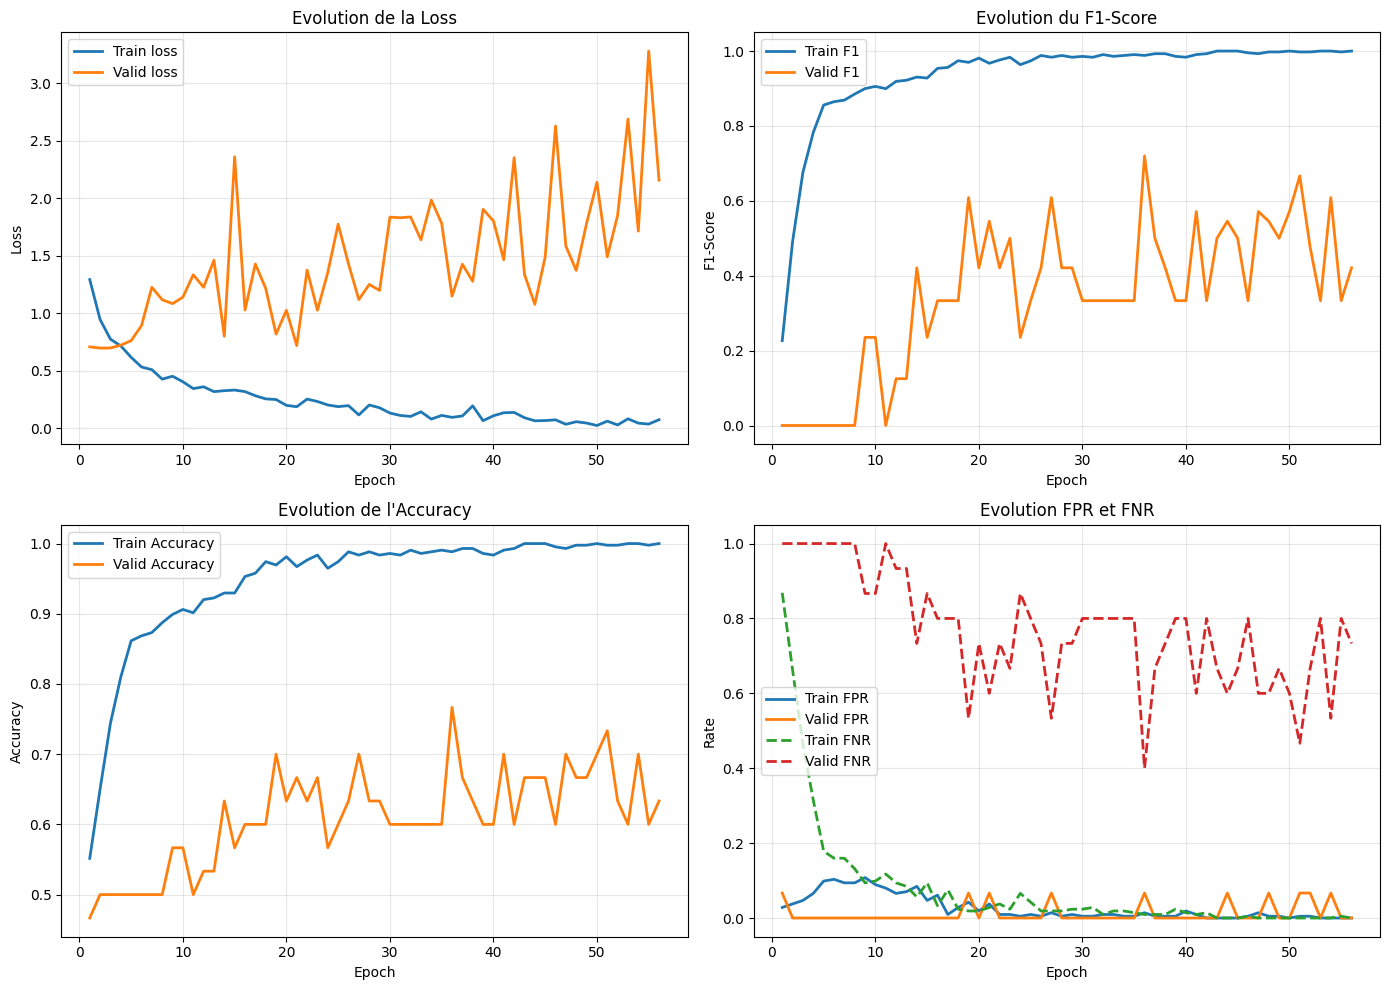

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import math
import matplotlib.pyplot as plt

# QUESTION 1 : STANDARDISATION PAR BANDE DE FRÉQUENCE

def calc_mean_std(X_train):
    mean = X_train.mean(axis=(0, 2), keepdims=True) 
    std = X_train.std(axis=(0, 2), keepdims=True)    
    std[std == 0] = 1.0
    return mean, std

def standardisation(X, mean, std):
    return (X - mean) / std

# 2. Les pulses acoustiques sont dans une gamme de fréquence spécifique c'est 
# pour cela que l'on va utiliser la standardisation par bande de fréquence.

# QUESTION 2 : CONSTRUCTION TRAIN/VALID/TEST

def create_train_valid_test_splits(csv_path, output_base_dir='dataset'):
    df = pd.read_csv(csv_path)
    df["filename"] = df["filename"].apply(lambda f: str(Path("Ressources") / Path(f).name))
    
    files = df["filename"].unique()
    train_files, temp_files = train_test_split(files, test_size=0.25, random_state=42)
    valid_files, test_files = train_test_split(temp_files, test_size=0.6, random_state=42)
    
    splits = {'train': train_files, 'valid': valid_files, 'test': test_files}
    output_base = Path(output_base_dir)
    output_base.mkdir(exist_ok=True)
    
    for split_name, split_files in splits.items():
        df_split = df[df["filename"].isin(split_files)]
        spectros_pos = get_all_spectros_pos(df_split, K_SHIFTS)
        spectros_neg = get_all_spectros_neg(df_split, K_SHIFTS)
        X, Y = generate_dataset(spectros_pos, spectros_neg, 
                                output_dir=str(output_base / split_name))
        print(f"{split_name}: {len(X)} samples ({Y.sum()} positifs, {len(Y) - Y.sum()} négatifs)")
    
    X_train = np.load(output_base / 'train' / 'x.npy')
    X_valid = np.load(output_base / 'valid' / 'x.npy')
    X_test  = np.load(output_base / 'test' / 'x.npy')

    mean, std = calc_mean_std(X_train)
    X_train = standardisation(X_train, mean, std)
    X_valid = standardisation(X_valid, mean, std)
    X_test  = standardisation(X_test,  mean, std)

    np.save(output_base / 'train' / 'x.npy', X_train)
    np.save(output_base / 'valid' / 'x.npy', X_valid)
    np.save(output_base / 'test' / 'x.npy',  X_test)
    
    print(f"\nStandardisation appliquée (par bande de fréquence)")
    print(f"Mean shape: {mean.shape}, Std shape: {std.shape}")

# QUESTION 3 : MLP

class MyMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes=[64, 32], dropout_rate=0.4):
        super().__init__()
        self.layers = nn.ModuleList()
        
        sizes = [input_size, 64, 32, 16] 
        
        for i in range(len(sizes) - 1):
            lineaire = nn.Linear(sizes[i], sizes[i+1])
            
            nn.init.xavier_uniform_(lineaire.weight)
            nn.init.zeros_(lineaire.bias)
            self.layers.append(lineaire) 
            self.layers.append(nn.Dropout(dropout_rate))
            self.layers.append(nn.ReLU())
            
        self.output_layer = nn.Linear(sizes[-1], 1)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return self.output_layer(x).squeeze(-1)

# QUESTION 4 : CHARGEMENT DATASET AVEC PYTORCH

def load_dataset(data_dir):
    data_path = Path(data_dir)
    X = np.load(data_path / 'x.npy')
    Y = np.load(data_path / 'y.npy')
    
    X_tensor = torch.from_numpy(X).float()
    Y_tensor = torch.from_numpy(Y).float()
    
    return TensorDataset(X_tensor, Y_tensor)


# QUESTION 6 : MÉTRIQUES D'ÉVALUATION

def compute_metrics(y_true, y_pred):
    y_pred = y_pred.int()
    y_true = y_true.int()

    TP = ((y_pred == 1) & (y_true == 1)).sum().item()
    TN = ((y_pred == 0) & (y_true == 0)).sum().item()
    FP = ((y_pred == 1) & (y_true == 0)).sum().item()
    FN = ((y_pred == 0) & (y_true == 1)).sum().item()
    
    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'fnr': fnr
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        total_loss += loss.item()
        
        preds = (torch.sigmoid(outputs) > threshold).float()
        all_preds.append(preds.cpu())
        all_labels.append(Y_batch.cpu())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = total_loss / len(loader)
    return metrics


# QUESTION 5 : BOUCLE D'ENTRAÎNEMENT

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

train_dataset = load_dataset('dataset/train')
valid_dataset = load_dataset('dataset/valid')

y_train = train_dataset.tensors[1]
num_pos = torch.sum(y_train)
num_neg = len(y_train) - num_pos
pos_weight = (num_neg / num_pos).to(torch.device('cpu')) 

# Hyperparametres
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 1e-3

model = MyMLP(input_size=303)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-2)
scheduler = OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE * 5,
    epochs=EPOCHS,
    steps_per_epoch=len(DataLoader(train_dataset, batch_size=BATCH_SIZE)),
    pct_start=0.3
)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print()
print(f"Entraînement lancé avec pos_weight: {pos_weight:.2f}")
print(f"Device: {device}")
print(f"Input size: {input_size}")
print(f"Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")
print(f"Architecture: 4 couches [128, 64, 32, 16]")
print(f"Dropout: 0.5 | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}\n")
print()

best_valid_f1 = 0.0
patience = 20
patience_counter = 0
best_model_state = None

history = {
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
    "train_precision": [],
    "valid_precision": [],
    "train_recall": [],
    "valid_recall": [],
    "train_f1": [],
    "valid_f1": [],
    "train_fpr": [],
    "valid_fpr": [],
    "train_fnr": [],
    "valid_fnr": []
}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    train_metrics = evaluate(model, train_loader, criterion, device, THRESHOLD)
    valid_metrics = evaluate(model, valid_loader, criterion, device, THRESHOLD)

    if valid_metrics['f1'] > best_valid_f1:
        best_valid_f1 = valid_metrics['f1']
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train - Loss: {train_loss:.4f} | Acc: {train_metrics['accuracy']:.3f} | "
            f"Prec: {train_metrics['precision']:.3f} | Rec: {train_metrics['recall']:.3f} | "
            f"F1: {train_metrics['f1']:.3f} | FPR: {train_metrics['fpr']:.3f} | FNR: {train_metrics['fnr']:.3f}")
    print(f"  Valid - Loss: {valid_metrics['loss']:.4f} | Acc: {valid_metrics['accuracy']:.3f} | "
            f"Prec: {valid_metrics['precision']:.3f} | Rec: {valid_metrics['recall']:.3f} | "
            f"F1: {valid_metrics['f1']:.3f} | FPR: {valid_metrics['fpr']:.3f} | FNR: {valid_metrics['fnr']:.3f}")
    print(f"  Best Valid F1: {best_valid_f1:.3f} | Patience: {patience_counter}/{patience}\n")
    
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_metrics['loss'])
    history["train_accuracy"].append(train_metrics['accuracy'])
    history["valid_accuracy"].append(valid_metrics['accuracy'])
    history["train_precision"].append(train_metrics['precision'])
    history["valid_precision"].append(valid_metrics['precision'])
    history["train_recall"].append(train_metrics['recall'])
    history["valid_recall"].append(valid_metrics['recall'])
    history["train_f1"].append(train_metrics['f1'])
    history["valid_f1"].append(valid_metrics['f1'])
    history["train_fpr"].append(train_metrics['fpr'])
    history["valid_fpr"].append(valid_metrics['fpr'])
    history["train_fnr"].append(train_metrics['fnr'])
    history["valid_fnr"].append(valid_metrics['fnr'])
    
    if patience_counter >= patience:
        print(f"Early stopping à l'epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\n=== Évaluation finale sur Test Set ===")
test_metrics = evaluate(model, test_loader, criterion, device, THRESHOLD)

print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.3f}")
print(f"Precision: {test_metrics['precision']:.3f}")
print(f"Recall: {test_metrics['recall']:.3f}")
print(f"F1-Score: {test_metrics['f1']:.3f}")
print(f"FPR: {test_metrics['fpr']:.3f}")
print(f"FNR: {test_metrics['fnr']:.3f}")

# torch.save(model.state_dict(), 'mlp_model.pth')
# print("\nModèle sauvegardé : mlp_model.pth")

epochs_arr = np.arange(1, len(history["train_loss"]) + 1)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

ax1.plot(epochs_arr, history["train_loss"], label="Train loss", linewidth=2)
ax1.plot(epochs_arr, history["valid_loss"], label="Valid loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Evolution de la Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_arr, history["train_f1"], label="Train F1", linewidth=2)
ax2.plot(epochs_arr, history["valid_f1"], label="Valid F1", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1-Score")
ax2.set_title("Evolution du F1-Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(epochs_arr, history["train_accuracy"], label="Train Accuracy", linewidth=2)
ax3.plot(epochs_arr, history["valid_accuracy"], label="Valid Accuracy", linewidth=2)
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Accuracy")
ax3.set_title("Evolution de l'Accuracy")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.plot(epochs_arr, history["train_fpr"], label="Train FPR", linewidth=2)
ax4.plot(epochs_arr, history["valid_fpr"], label="Valid FPR", linewidth=2)
ax4.plot(epochs_arr, history["train_fnr"], label="Train FNR", linewidth=2, linestyle='--')
ax4.plot(epochs_arr, history["valid_fnr"], label="Valid FNR", linewidth=2, linestyle='--')
ax4.set_xlabel("Epoch")
ax4.set_ylabel("Rate")
ax4.set_title("Evolution FPR et FNR")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()